# 08 — Facial Expression Synchrony (two subjects)

Quantifies how closely two subjects' facial expressions track each other over time. Higher synchrony is associated with rapport, social connection, and mutual engagement in the interaction literature — and is a potential mediator of trust formation in dyadic contexts.

**Input:** two `<stem>_merged.parquet` files produced by `00_pipeline.ipynb`, one per subject, recorded **simultaneously** (otherwise "synchrony" is meaningless).

**What's computed:**
1. **Windowed Pearson correlation** — rolling-window correlation between A and B for each AU and each emotion, with a 5 s window that steps 1 s at a time. Shows how synchrony evolves across the interaction.
2. **Lagged cross-correlation** — for each AU, shift B by ±3 s, compute global Pearson at each lag. Identifies per-AU best correlation and best lag (who leads whom).
3. **Overall synchrony score** — mean of the top-k AUs by |best correlation|. Provides a single headline number per dyad.

**Outputs:** per-AU table, synchrony heatmap over time, overall score.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

## Config

**Inputs:** set `STEM_A` and `STEM_B` to the filename stems of the two subjects' pipeline outputs (e.g. `subjectA` and `subjectB`).

**Single-subject testing:** if you only have one video, set both stems to the same value. The notebook will produce trivial synchrony (correlation = 1.0 at lag 0) — useful for validating that the code runs, but uninformative as an actual synchrony measurement.

In [2]:
STEM_A = "player1"      # subject A
STEM_B = "player2"      # subject B (set to a different stem when you have a second video)

WINDOW_SECONDS = 5.0   # windowed-Pearson window size
STEP_SECONDS   = 1.0   # step between consecutive windows
MAX_LAG_SECONDS = 3.0  # ± lag range for cross-correlation
TOP_K = 5              # number of top-correlated AUs to average for the overall score

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"

print(f"Subject A: {DATA_DIR / (STEM_A + '_merged.parquet')}")
print(f"Subject B: {DATA_DIR / (STEM_B + '_merged.parquet')}")
if STEM_A == STEM_B:
    print("\n⚠ Both stems are identical — results will show trivial 1.0 synchrony. Use two different videos for real analysis.")

Subject A: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/player1_merged.parquet
Subject B: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/player2_merged.parquet


In [3]:
def load_subject(stem: str):
    df = pd.read_parquet(DATA_DIR / f"{stem}_merged.parquet")
    meta = pd.read_json(DATA_DIR / f"{stem}_merged.meta.json", typ="series")
    return df, float(meta["effective_fps"])

dfA, fpsA = load_subject(STEM_A)
dfB, fpsB = load_subject(STEM_B)
print(f"A: {len(dfA)} frames @ {fpsA:.2f} fps")
print(f"B: {len(dfB)} frames @ {fpsB:.2f} fps")

A: 392 frames @ 12.00 fps
B: 397 frames @ 12.00 fps


## 1. Align to a common time grid

**What this section does:** puts both subjects' time series on the same regularly-spaced timestamp grid, interpolating where needed.

**Why interpolate:** even if both videos were recorded simultaneously at the same nominal fps, small timing offsets and differing `SKIP_FRAMES` settings in the pipeline can produce slightly misaligned sample points. Interpolation to a shared grid is the standard first step in cross-subject time-series analysis.

**Grid choice:** use the lower of the two effective fps (to avoid over-interpolating the slower stream). Covers the overlapping time range only.

In [4]:
AU_COLS = sorted([c for c in dfA.columns if c.startswith("pf_AU")])
EMO_COLS = [f"pf_{e}" for e in ["anger","disgust","fear","happiness","sadness","surprise","neutral"]]
SIGNAL_COLS = [c for c in AU_COLS + EMO_COLS if c in dfA.columns and c in dfB.columns]
print(f"{len(AU_COLS)} AUs + {len(EMO_COLS)} emotions -> {len(SIGNAL_COLS)} signals tracked")

common_fps = min(fpsA, fpsB)
common_dt = 1.0 / common_fps
t_start = max(dfA["timestamp"].min(), dfB["timestamp"].min())
t_end   = min(dfA["timestamp"].max(), dfB["timestamp"].max())
grid = np.arange(t_start, t_end + 1e-9, common_dt)
print(f"common grid: {len(grid)} samples @ {common_fps:.2f} fps, {t_start:.2f}s to {t_end:.2f}s")

def resample(df, cols, grid):
    out = pd.DataFrame({"timestamp": grid})
    t_src = df["timestamp"].to_numpy()
    for c in cols:
        y = df[c].to_numpy()
        mask = ~np.isnan(y)
        if mask.sum() < 2:
            out[c] = np.nan
        else:
            out[c] = np.interp(grid, t_src[mask], y[mask])
    return out

A = resample(dfA, SIGNAL_COLS, grid)
B = resample(dfB, SIGNAL_COLS, grid)
print(f"A resampled: {A.shape}, B resampled: {B.shape}")

20 AUs + 7 emotions -> 27 signals tracked
common grid: 392 samples @ 12.00 fps, 0.00s to 32.58s
A resampled: (392, 28), B resampled: (392, 28)


## 2. Windowed Pearson correlation

**What this section does:** for each signal (AU or emotion), slides a `WINDOW_SECONDS`-long window across the aligned time series and computes the Pearson correlation between A and B in each window. Window advances by `STEP_SECONDS` between computations.

**Why windowed, not global:** synchrony waxes and wanes within an interaction. A global Pearson (one number per AU over the whole video) averages over moments of high and low synchrony. Windowed gives you a synchrony *time series*.

**Window size tradeoff:** short windows (2–3 s) are responsive to brief synchrony episodes but noisy. Long windows (10+ s) are stable but smear over transitions. 5 s is a common compromise in the literature.

In [5]:
def windowed_pearson(a: np.ndarray, b: np.ndarray, window: int, step: int):
    """Return (centers_idx, corrs) arrays for rolling Pearson."""
    n = len(a)
    if n < window:
        return np.array([]), np.array([])
    centers = []
    corrs = []
    for start in range(0, n - window + 1, step):
        end = start + window
        x = a[start:end]; y = b[start:end]
        if np.isnan(x).any() or np.isnan(y).any() or np.std(x) == 0 or np.std(y) == 0:
            c = np.nan
        else:
            c = float(np.corrcoef(x, y)[0, 1])
        centers.append(start + window // 2)
        corrs.append(c)
    return np.array(centers), np.array(corrs)

win = max(2, int(round(WINDOW_SECONDS * common_fps)))
step = max(1, int(round(STEP_SECONDS * common_fps)))

rows = []
for col in SIGNAL_COLS:
    centers, corrs = windowed_pearson(A[col].to_numpy(), B[col].to_numpy(), win, step)
    if len(centers) == 0:
        continue
    window_times = grid[centers]
    for t, c in zip(window_times, corrs):
        rows.append({"signal": col, "t": float(t), "corr": float(c) if not np.isnan(c) else np.nan})
wc = pd.DataFrame(rows)
print(f"Windowed correlations: {wc.shape[0]} (signal, window) pairs, "
      f"{wc['signal'].nunique()} signals × {wc.groupby('signal').size().iloc[0]} windows")
wc.head(3)

Windowed correlations: 756 (signal, window) pairs, 27 signals × 28 windows


,signal,t,corr
0,pf_AU01,2.5,0.314068
1,pf_AU01,3.5,0.221198
2,pf_AU01,4.5,0.181806


## 3. Lagged cross-correlation

**What this section does:** shifts B by −MAX_LAG to +MAX_LAG seconds relative to A and computes the global Pearson at each lag. Answers *who leads whom* — if B leads A by 0.8 s on AU12 (smile), seeing A's smile is a delayed echo of B's.

**Output per AU:**
- `best_corr` — max correlation over all lags (can be positive or negative; we report the one with largest |value|).
- `best_lag_s` — the lag (seconds) at which best_corr occurred. **Sign convention: positive lag = B leads A** (B's signal was shifted earlier to match A, equivalently A's response came later).
- `corr_at_zero` — for reference, the correlation at zero lag.

**Why max-|corr| instead of max-corr:** strong *negative* correlation is also informative (A smiles when B frowns) and shouldn't be discarded. Most AUs in rapport settings correlate positively, but mixed-polarity interactions exist.

**Interpretation tip:** if best_lag is at the edge of ±MAX_LAG, the true lag may be outside the search range — consider widening.

In [6]:
def lagged_cross_corr(a: np.ndarray, b: np.ndarray, max_lag_samples: int):
    """Return (lags, corrs): correlations at lags from -max_lag..+max_lag (samples)."""
    lags = np.arange(-max_lag_samples, max_lag_samples + 1)
    corrs = np.full_like(lags, np.nan, dtype=float)
    for i, k in enumerate(lags):
        if k < 0:
            x, y = a[-k:], b[:k]
        elif k > 0:
            x, y = a[:-k], b[k:]
        else:
            x, y = a, b
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 3 or np.std(x[mask]) == 0 or np.std(y[mask]) == 0:
            continue
        corrs[i] = np.corrcoef(x[mask], y[mask])[0, 1]
    return lags, corrs

max_lag_samples = int(round(MAX_LAG_SECONDS * common_fps))

best_rows = []
for col in SIGNAL_COLS:
    a = A[col].to_numpy(); b = B[col].to_numpy()
    lags, corrs = lagged_cross_corr(a, b, max_lag_samples)
    if np.all(np.isnan(corrs)):
        continue
    best_idx = int(np.nanargmax(np.abs(corrs)))
    corr_zero = corrs[np.where(lags == 0)[0][0]]
    best_rows.append({
        "signal": col,
        "best_corr": round(float(corrs[best_idx]), 3),
        "best_lag_s": round(float(lags[best_idx] / common_fps), 2),
        "corr_at_zero": round(float(corr_zero), 3),
    })
best_df = pd.DataFrame(best_rows).sort_values("best_corr", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
best_df

,signal,best_corr,best_lag_s,corr_at_zero
0,pf_surprise,0.407,2.58,-0.043
1,pf_AU17,-0.348,-3.00,-0.116
2,pf_AU20,-0.333,-2.25,-0.077
3,pf_AU04,0.329,2.83,0.088
4,pf_AU15,-0.303,-1.67,-0.148
5,pf_AU24,-0.288,-2.67,-0.117
6,pf_AU23,-0.256,1.83,0.019
7,pf_AU02,0.230,0.17,0.227
8,pf_AU14,-0.226,2.50,-0.047
9,pf_fear,0.220,1.42,-0.008


## 4. Overall synchrony score

**What this is:** the mean of the top-K absolute correlations across all AUs and emotions. Gives a single headline number per dyad.

**Why top-K:** synchrony typically concentrates in a handful of emotionally-loaded AUs (e.g. AU12 smiles, AU04 brow). Averaging over *all* AUs dilutes the signal with AUs that neither subject uses much.

**Defensible values of K:** 3–10. We default to 5. Report K alongside the score.

In [7]:
top_k = best_df.head(TOP_K)
overall = float(top_k["best_corr"].abs().mean())
print(f"Top {TOP_K} signals by |best_corr|:")
print(top_k.to_string(index=False))
print(f"\nOverall synchrony score (mean top-{TOP_K} |corr|): {overall:.3f}")

Top 5 signals by |best_corr|:
     signal  best_corr  best_lag_s  corr_at_zero
pf_surprise      0.407        2.58        -0.043
    pf_AU17     -0.348       -3.00        -0.116
    pf_AU20     -0.333       -2.25        -0.077
    pf_AU04      0.329        2.83         0.088
    pf_AU15     -0.303       -1.67        -0.148

Overall synchrony score (mean top-5 |corr|): 0.344


## 5. Synchrony heatmap over time

**What this chart shows:** signals on the y-axis, time on the x-axis, windowed Pearson correlation as color. Red = positive synchrony, blue = negative (anti-phase), white = no correlation.

**How to read it:** horizontal bands of sustained red = an AU where A and B consistently tracked. Vertical bands of red across many AUs = a moment of broad synchrony (typically an emotional beat in the conversation). Patchy randomness = no meaningful synchrony at that time.

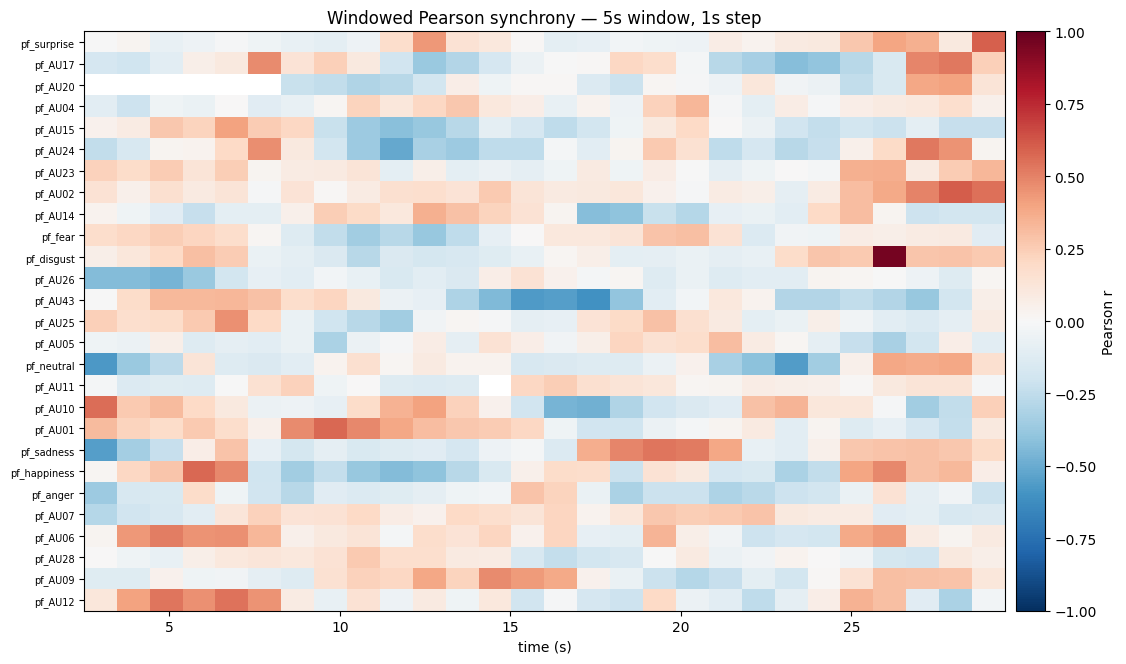

In [8]:
pivot = wc.pivot(index="signal", columns="t", values="corr")
# Sort rows by magnitude of best correlation so strong AUs show at the top
order = best_df.set_index("signal").index.tolist() if len(best_df) else pivot.index.tolist()
pivot = pivot.reindex([s for s in order if s in pivot.index])

fig, ax = plt.subplots(figsize=(12, max(4, 0.25 * len(pivot))))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1,
               extent=[pivot.columns.min(), pivot.columns.max(), len(pivot), 0])
ax.set_yticks(np.arange(len(pivot)) + 0.5)
ax.set_yticklabels(pivot.index, fontsize=7)
ax.set_xlabel("time (s)")
ax.set_title(f"Windowed Pearson synchrony — {WINDOW_SECONDS:.0f}s window, {STEP_SECONDS:.0f}s step")
cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("Pearson r")
plt.tight_layout()
plt.show()

## 6. Save results

In [9]:
out_prefix = f"{STEM_A}__vs__{STEM_B}"
PER_AU_PATH = DATA_DIR / f"{out_prefix}_synchrony_per_au.parquet"
WINDOWED_PATH = DATA_DIR / f"{out_prefix}_synchrony_windowed.parquet"

best_df.to_parquet(PER_AU_PATH, index=False)
wc.to_parquet(WINDOWED_PATH, index=False)
print(f"Saved: {PER_AU_PATH}")
print(f"Saved: {WINDOWED_PATH}")
print(f"\nOverall synchrony score: {overall:.3f}  (mean top-{TOP_K} |corr|)")

Saved: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/player1__vs__player2_synchrony_per_au.parquet
Saved: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/player1__vs__player2_synchrony_windowed.parquet

Overall synchrony score: 0.344  (mean top-5 |corr|)
